In [118]:
import pandas as pd
import nflreadpy as nfl
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import ssl
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.cluster import KMeans                   

from statsmodels.stats.anova import anova_lm
ssl._create_default_https_context = ssl._create_unverified_context

In [4]:
df_list = []
for file in os.listdir(r'data'):
    os.path.join('data',file)
    year = file.split(".")[0]
    df = pd.read_parquet(os.path.join('data',file))
    df['year']=year
    df_list.append(df)

madden_data = pd.concat(df_list,axis=0).reset_index(drop=True)

In [5]:
combine_data = nfl.load_combine()
combine_cols = combine_data.columns
combine_data_cleaned = pd.DataFrame(combine_data,columns=combine_cols)

In [6]:
pdp_data = nfl.load_pbp(list(range(2020,2026,1)))
pdp_data_cols = pdp_data.columns
pdp_data_cleaned = pd.DataFrame(pdp_data,columns=pdp_data_cols)

In [7]:
madden_qb_data = madden_data[madden_data['position']=='QB']

In [8]:
madden_qb_cols = ['fullname','agility', 'acceleration', 'speed', 'stamina','playrecognition','changeofdirection','year']

In [9]:
madden_qb_data_cleaned=madden_qb_data[madden_qb_cols]

In [10]:
qb_combine_data=combine_data_cleaned[combine_data_cleaned['pos']=='QB']

In [11]:

qb_height_weight = qb_combine_data[['player_name','ht','wt']]

In [12]:
madden_data_with_height_df = madden_qb_data_cleaned.merge(qb_height_weight,how='left',left_on='fullname',right_on='player_name')

In [13]:
pdp_data_cleaned['year'] = pdp_data_cleaned['game_id'].str.split("_").str[0]

In [14]:
pbp_defensive_data = nfl.load_participation(list(range(2020,2026,1)))
pbp_defensive_data_cols = pbp_defensive_data.columns
pbp_defensive_data_cleaned = pd.DataFrame(pbp_defensive_data,columns=pbp_defensive_data_cols)

In [15]:
pdp_data_cleaned['game_play_id'] = (
      pdp_data_cleaned['game_id'] + '_' +                                                                    
      pdp_data_cleaned['play_id'].astype(int).astype(str)                                                    
  )                                                                                                          
                                                                                                             
                                                                                         
pbp_defensive_data_cleaned['game_play_id'] = (
      pbp_defensive_data_cleaned['nflverse_game_id'] + '_' +
      pbp_defensive_data_cleaned['play_id'].astype(int).astype(str)
  )         

In [16]:
master_pbp_data = pdp_data_cleaned.merge(pbp_defensive_data_cleaned,how='left',on='game_play_id')
master_pbp_data['passer_year_id']= (master_pbp_data['year'].astype(str)  + '_' +                                                                    
      master_pbp_data['passer_player_id'].astype(str))

In [17]:
pbp_qb_data = master_pbp_data[['passer_player_name','passer_player_id','shotgun','play_type','pass_attempt','qb_dropback','qb_scramble','air_yards','rusher_player_id', 'pass_length','complete_pass', 'pass_location', 'rushing_yards', 
'yards_gained','interception', 'sack', 'qb_hit', 'incomplete_pass' , 'was_pressure', 'qb_epa','year','epa']]

In [18]:
gb_yearly_throw_count = pbp_qb_data[pbp_qb_data['play_type']=='pass'].groupby(['year','passer_player_id'],as_index=False).size()

In [19]:
gb_yearly_throw_count['passer_year_id'] =  (gb_yearly_throw_count['year'].astype(str)  + '_' +                                                                    
      gb_yearly_throw_count['passer_player_id'].astype(str))   

In [20]:
eligible_qb_ids = list(gb_yearly_throw_count[gb_yearly_throw_count['size']>=200]['passer_year_id'].unique())

In [21]:
pbp_qb_data['passer_year_id'] =  (pbp_qb_data['year'].astype(str)  + '_' +                                                                    
      pbp_qb_data['passer_player_id'].astype(str))

pbp_qb_data['rusher_player_year_id'] =  (pbp_qb_data['year'].astype(str)  + '_' +                                                                    
      pbp_qb_data['rusher_player_id'].astype(str)) 

In [22]:
pbp_qb_data=pbp_qb_data[pbp_qb_data['play_type']!='no_play']

In [23]:
qb_run_data = pbp_qb_data[pbp_qb_data['rusher_player_year_id'].isin(eligible_qb_ids)]

In [24]:
qb_eligiable_df = pbp_qb_data[(pbp_qb_data['play_type']=='pass')&(pbp_qb_data['passer_year_id'].isin(eligible_qb_ids))]

In [25]:
scramble_stats = qb_run_data[qb_run_data['qb_scramble'] == 1].groupby('rusher_player_year_id',       
  as_index=False).agg(                                                                                 
      scrambles=('qb_scramble', 'sum'),                                                                
      avg_scramble_yards=('yards_gained', 'mean'),                                                          
      scramble_epa=('qb_epa', 'mean')
  )

dropback_counts =  pbp_qb_data[pbp_qb_data['passer_year_id'].isin(eligible_qb_ids)].groupby('passer_year_id',           
  as_index=False).agg(
      dropbacks=('qb_dropback', 'sum')                                                                 
  )                       

In [26]:
scramble_stats = scramble_stats.merge(dropback_counts, left_on='rusher_player_year_id',              
  right_on='passer_year_id').assign(
      scramble_rate=lambda x: x['scrambles'] / x['dropbacks']                                          
  ) 



In [27]:
qb_run_data_aggreate=qb_run_data[qb_run_data['qb_scramble']==0].groupby(['rusher_player_year_id'],as_index=False).agg(
    designed_runs= ('rusher_player_year_id','count'),avg_yards_gained = ('yards_gained','mean')).merge(                                                                                             
      dropback_counts.rename(columns={'passer_year_id': 'rusher_player_year_id'}),                     
      on='rusher_player_year_id').assign(designed_run_rate=lambda x: x['designed_runs'] / x['dropbacks']) 


qb_run_data_aggreate=qb_run_data_aggreate.rename({'rusher_player_year_id':'passer_year_id'},axis=1)

In [28]:
qb_pass_stats_data = qb_eligiable_df.groupby(['passer_year_id', 'pass_length'],as_index=False).agg(                               
      attempts=('pass_attempt', 'sum'),                                                      
      completions=('complete_pass', 'sum'),                                                     
      avg_air_yards=('air_yards', 'mean'),                                                     
      qb_epa_per_attempt=('qb_epa', 'mean'),
  ).assign(completion_pct=lambda x: x['completions'] / x['attempts']) 

In [29]:
qb_pass_stats_data_pivot = qb_pass_stats_data.pivot(index='passer_year_id', columns='pass_length', values=['avg_air_yards', 'qb_epa_per_attempt','completion_pct'])

In [30]:
qb_pass_stats_data_pivot.columns = ['_'.join(col).strip() for col in qb_pass_stats_data_pivot.columns]                                                                    
qb_pass_stats_data_pivot_clean = qb_pass_stats_data_pivot.reset_index()



In [31]:
dropback_counts_mistake = qb_eligiable_df.groupby(['passer_year_id', 'was_pressure'], as_index=False).agg(
      dropbacks=('qb_dropback', 'sum')                                                                 
  ) 

In [32]:
qb_pressure_mistake_data=qb_eligiable_df.groupby(['passer_year_id', 'was_pressure'], as_index=False).agg(          
      attempts=('pass_attempt', 'sum'),
      sacks=('sack', 'sum'),                                                                                 
      ints=('interception', 'sum'),
      mean_epa=('qb_epa', 'mean')).merge(dropback_counts_mistake, on=['passer_year_id', 'was_pressure']).assign(
      sack_rate=lambda x: x['sacks'] / x['dropbacks'],                                                 
      int_rate=lambda x: x['ints'] / x['attempts']
  ).pivot(index='passer_year_id', columns='was_pressure', values=['mean_epa', 'sack_rate', 'int_rate'])

In [33]:
qb_pressure_mistake_data.columns = ['_pressure_'.join([col[0], str(col[1])]).strip() for col in qb_pressure_mistake_data.columns]                                                                    
qb_pressure_mistake_data_clean = qb_pressure_mistake_data.reset_index()

In [34]:
overall_epa = qb_eligiable_df.groupby('passer_year_id', as_index=False).agg(
      overall_epa_per_dropback=('qb_epa', 'mean')                                                      
  )    

In [35]:
aggregate_data_list = [qb_pass_stats_data_pivot_clean,qb_run_data_aggreate,scramble_stats,overall_epa]

In [36]:
for d in aggregate_data_list:
    qb_pressure_mistake_data_clean=qb_pressure_mistake_data_clean.merge(d,how='left',on='passer_year_id')

In [37]:
master_aggregate_data = qb_pressure_mistake_data_clean.copy()

In [38]:
master_passer_id_name_df = master_pbp_data[master_pbp_data['passer_player_id'].notna()][['passer_player_id','passer_player_name']]

In [39]:
master_passer_id_name_dict=dict(zip(master_passer_id_name_df['passer_player_id'],master_passer_id_name_df['passer_player_name']))

In [40]:
master_aggregate_data[['year','passer_id']] = master_aggregate_data['passer_year_id'].str.split("_",expand=True)

In [41]:
master_aggregate_data['passer_name']=master_aggregate_data['passer_id'].map(master_passer_id_name_dict)

In [42]:
madden_rename_dict = {'Michael Penix Jr.':'Michael Penix'}

In [43]:

madden_data_with_height_df['fullname']=madden_data_with_height_df['fullname'].replace(madden_rename_dict)

In [44]:
name_split = madden_data_with_height_df['fullname'].str.split(" ", expand=True)                    
madden_data_with_height_df['f_name'] = name_split[0]                                             
madden_data_with_height_df['l_name'] = name_split[1].where(name_split[2].isna(), other=np.nan)  

In [45]:
madden_data_with_height_df['name_match']=madden_data_with_height_df['f_name'].str[0] + "." + madden_data_with_height_df['l_name']


In [46]:
player_height=madden_data_with_height_df['ht'].str.split("-")
madden_data_with_height_df['h_feet'] = player_height.str[0].astype(float)                                             
madden_data_with_height_df['h_inches'] = player_height.str[1].astype(float)                                               
madden_data_with_height_df['height_inches'] = (madden_data_with_height_df['h_feet'] * 12 +           
                                                  madden_data_with_height_df['h_inches']) 

madden_data_with_height_df=madden_data_with_height_df.drop(['h_feet','h_inches','ht','f_name','l_name','fullname','player_name','wt'],axis=1)

In [47]:
master_aggregate_data['passer_name_year_id'] = master_aggregate_data['year']+'_'+master_aggregate_data['passer_name']

In [48]:
madden_data_with_height_df['passer_name_year_id'] = madden_data_with_height_df['year']+'_'+madden_data_with_height_df['name_match']

In [49]:
master_passer_aggregate_data = master_aggregate_data.merge(madden_data_with_height_df,how='left',on='passer_name_year_id')

In [50]:
mising_height_dict = {'N.Mullens':72,'T.Heinicke':73,'T.Siemian':75,'T.Huntley':73,'T.DeVito':74,'C.Ward':74}

In [51]:
master_passer_aggregate_data['height_inches']=master_passer_aggregate_data['height_inches'].fillna(master_passer_aggregate_data['name_match'].map(mising_height_dict))

In [52]:
master_passer_aggregate_data = master_passer_aggregate_data.drop(
      columns=['dropbacks_y', 'year_y', 'rusher_player_year_id', 'name_match']                         
  ) 

In [53]:
string_cols = ['passer_year_id', 'passer_id', 'passer_name', 'passer_name_year_id', 'name_match',
  'year_x']                                                                                            
   
numeric_cols = master_passer_aggregate_data.columns.difference(                                      
    string_cols +                                                                                  
list(master_passer_aggregate_data.select_dtypes(include=['float64','int64']).columns)                
)
                                                                                                       
master_passer_aggregate_data[numeric_cols] = master_passer_aggregate_data[numeric_cols].astype(float).fillna(0)

In [129]:
master_passer_aggregate_data=master_passer_aggregate_data.fillna(0)

In [130]:
master_passer_aggregate_data

,passer_year_id,mean_epa_pressure_False,mean_epa_pressure_True,sack_rate_pressure_False,sack_rate_pressure_True,int_rate_pressure_False,int_rate_pressure_True,avg_air_yards_deep,avg_air_yards_short,qb_epa_per_attempt_deep,...,passer_name_year_id,agility,acceleration,speed,stamina,playrecognition,changeofdirection,height_inches,label,label_gmm
0,2020_00-0019596,0.391219,0.026525,0.0,0.000000,0.016544,0.030000,26.270588,4.253054,0.519608,...,2020_T.Brady,70.000000,66.000000,60.00000,99.000000,20.000000,66.000000,76.0,3,4
1,2020_00-0020531,0.298195,-0.054201,0.0,0.000000,0.017241,0.026549,20.096774,3.701754,0.752502,...,2020_D.Brees,68.000000,72.000000,67.00000,77.000000,27.000000,71.000000,72.0,3,4
2,2020_00-0022924,0.150013,0.031349,0.0,0.000000,0.018762,0.027972,24.837838,3.598230,0.177842,...,2020_B.Roethlisberger,67.000000,78.000000,72.00000,85.000000,19.000000,63.000000,77.0,2,0
3,2020_00-0022942,0.250560,0.271883,0.0,0.000000,0.020501,0.013605,23.558824,3.795455,0.638481,...,2020_P.Rivers,59.000000,70.000000,65.00000,92.000000,26.000000,60.000000,77.0,3,4
4,2020_00-0023436,0.193646,-0.447399,0.0,0.000000,0.016667,0.069444,25.241379,2.484305,0.596408,...,2020_A.Smith,77.000000,81.000000,75.00000,75.000000,31.000000,61.000000,76.0,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,2025_00-0040668,0.088065,-0.659555,0.0,0.214953,0.031250,0.056075,27.000000,3.005714,0.127921,...,2025_S.Sanders,81.000000,81.000000,78.00000,92.000000,42.000000,79.000000,74.0,1,3
215,2025_00-0040676,0.092797,-0.795311,0.0,0.297297,0.009828,0.016216,24.215054,3.727477,0.250158,...,2025_C.Ward,82.949654,86.979724,83.61522,81.050454,20.919435,78.855184,74.0,1,3
216,2025_00-0040691,0.234810,-0.517425,0.0,0.312500,0.011407,0.017857,26.343750,3.967153,0.323694,...,2025_J.Dart,82.000000,85.000000,84.00000,90.000000,28.000000,80.000000,74.0,6,2
217,2025_00-0040704,-0.132831,-0.428469,0.0,0.316667,0.013889,0.000000,21.523810,3.840491,-0.316494,...,2025_D.Gabriel,79.000000,86.000000,83.00000,91.000000,29.000000,78.000000,71.0,1,3


In [ ]:
pdp_data = nfl.load_pbp(list(range(2020,2026,1)))
pdp_data_cols = pdp_data.columns
pdp_data_cleaned = pd.DataFrame(pdp_data,columns=pdp_data_cols)

In [55]:
scaler = StandardScaler()



In [56]:
scaled_data = scaler.fit_transform(master_passer_aggregate_data[numeric_cols])



In [134]:
master_passer_aggregate_data['sack_rate_pressure_False'].value_counts()

sack_rate_pressure_False
0.000000    217
0.002604      1
0.002304      1
Name: count, dtype: int64

In [57]:
pca = PCA(n_components=.95)
data_pca = pca.fit_transform(scaled_data)

In [126]:
loadings = pd.DataFrame(                    
      pca.components_,                                                                    
      columns=master_passer_aggregate_data[numeric_cols].columns,                         
      index=[f'PC{i+1}' for i in range(pca.n_components_)]                                
  )   

In [139]:
loadings

,avg_air_yards_deep,avg_air_yards_short,avg_scramble_yards,avg_yards_gained,completion_pct_deep,completion_pct_short,designed_run_rate,dropbacks_x,int_rate_pressure_False,int_rate_pressure_True,mean_epa_pressure_False,mean_epa_pressure_True,overall_epa_per_dropback,qb_epa_per_attempt_deep,qb_epa_per_attempt_short,sack_rate_pressure_False,sack_rate_pressure_True,scramble_epa,scramble_rate,scrambles
PC1,-0.003655,0.075084,0.000285,-0.011310,0.289194,0.258415,0.037479,0.291036,-0.210181,-0.040809,0.412447,0.237029,0.434721,0.328089,0.385905,-0.024994,-0.140512,0.002152,-0.007917,0.139939
PC2,0.183895,0.087631,0.361322,0.397913,-0.081282,-0.011648,0.396902,0.011245,0.037469,-0.048876,-0.003177,-0.047468,-0.037122,-0.007693,0.002577,0.008642,0.106614,0.260364,0.475571,0.438539
PC3,-0.031134,-0.358180,0.030593,-0.174005,-0.144038,0.307391,-0.143964,0.109606,-0.184958,-0.233429,0.093967,-0.461858,0.050819,-0.062838,0.134901,0.191164,0.556094,0.049178,0.012649,0.087268
PC4,-0.380190,0.296172,0.107309,-0.054202,0.484557,-0.310715,-0.026598,-0.084188,0.213013,-0.193065,0.058106,-0.241413,-0.011012,0.372411,-0.147166,-0.032313,0.324074,0.028837,0.040322,-0.029157
PC5,-0.070643,-0.085538,0.466448,-0.316699,-0.029911,-0.050069,-0.329869,0.254625,0.117000,-0.115099,-0.132901,0.209501,-0.018596,-0.048372,-0.049024,-0.040790,-0.147464,0.599170,-0.121647,0.044503
PC6,0.467267,-0.420723,-0.163946,-0.056743,0.212202,-0.200599,-0.042021,0.317349,0.008891,-0.097299,-0.143091,0.071042,-0.104543,0.392750,-0.351053,0.085090,-0.021092,-0.151258,0.048540,0.174359
PC7,-0.023958,-0.137833,0.187879,0.054067,0.162728,-0.024891,0.050099,0.049120,-0.368587,0.742642,0.133199,-0.283096,-0.086836,0.104020,-0.173372,-0.142609,0.018417,0.185590,-0.114468,-0.091013
PC8,-0.172364,0.215210,-0.009861,-0.010519,-0.022093,-0.230789,-0.062978,0.175933,-0.232208,0.126426,-0.017484,0.030261,-0.053242,-0.081250,-0.007284,0.852586,-0.109470,-0.040174,0.039192,0.111558
PC9,-0.406395,-0.027637,-0.080937,-0.187214,-0.019778,0.068884,-0.147706,0.374659,0.213342,0.285606,-0.102700,-0.004090,-0.058607,-0.177027,-0.001558,-0.244450,-0.020137,-0.342703,0.291722,0.435916
PC10,0.509651,0.364718,-0.020016,-0.132094,-0.035669,0.098246,-0.159504,0.097905,0.550898,0.337531,0.133641,-0.169631,0.081946,-0.001845,0.109106,0.144966,0.175673,0.027003,-0.090259,0.003306


In [131]:
feature_importance = (loadings**2 * pca.explained_variance_ratio_[:,
np.newaxis]).sum(axis=0)                                                                
feature_importance = feature_importance.sort_values(ascending=False) 

In [143]:
dominant_pc = loadings.abs().idxmax(axis=0)
dominant_loading = loadings.abs().max(axis=0)                                           
                                                                                        
summary = pd.DataFrame({                
    'weighted_importance': feature_importance,                                          
    'dominant_pc': dominant_pc,                                                         
    'dominant_loading': dominant_loading.round(3)
}).sort_values('weighted_importance', ascending=False)                                  
                                        
summary['dominant_pc_label'] = summary['dominant_pc'] + ' (' +summary['dominant_loading'].astype(str) + ')'                                           
print(summary[['weighted_importance', 'dominant_pc_label']].to_string())

                          weighted_importance dominant_pc_label
sack_rate_pressure_False             0.049973       PC8 (0.853)
dropbacks_x                          0.049621      PC12 (0.606)
int_rate_pressure_True               0.049565       PC7 (0.743)
avg_air_yards_deep                   0.049558       PC10 (0.51)
int_rate_pressure_False              0.049548      PC10 (0.551)
scramble_rate                        0.048983      PC12 (0.486)
avg_air_yards_short                  0.048773      PC11 (0.454)
mean_epa_pressure_True               0.048539       PC3 (0.462)
scrambles                            0.048510       PC2 (0.439)
qb_epa_per_attempt_short             0.048432       PC1 (0.386)
qb_epa_per_attempt_deep              0.048393       PC6 (0.393)
sack_rate_pressure_True              0.047917       PC3 (0.556)
completion_pct_deep                  0.047824       PC4 (0.485)
designed_run_rate                    0.047220      PC13 (0.539)
completion_pct_short                 0.0

In [145]:
summary.to_csv('pca_importance.csv')

In [138]:
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.3f} across{pca.n_components_} components\n")      
print(feature_importance.round(4))   

Total variance explained: 0.957 across13 components

sack_rate_pressure_False    0.0500
dropbacks_x                 0.0496
int_rate_pressure_True      0.0496
avg_air_yards_deep          0.0496
int_rate_pressure_False     0.0495
scramble_rate               0.0490
avg_air_yards_short         0.0488
mean_epa_pressure_True      0.0485
scrambles                   0.0485
qb_epa_per_attempt_short    0.0484
qb_epa_per_attempt_deep     0.0484
sack_rate_pressure_True     0.0479
completion_pct_deep         0.0478
designed_run_rate           0.0472
completion_pct_short        0.0471
overall_epa_per_dropback    0.0471
mean_epa_pressure_False     0.0470
avg_yards_gained            0.0468
scramble_epa                0.0445
avg_scramble_yards          0.0420
dtype: float64


In [128]:
feature_importance = (loadings**2 * pca.explained_variance_ratio_[:,np.newaxis]).sum(axis=0)                                                   
feature_importance = feature_importance.sort_values(ascending=False)                    
print(feature_importance) 

sack_rate_pressure_False    0.049973
dropbacks_x                 0.049621
int_rate_pressure_True      0.049565
avg_air_yards_deep          0.049558
int_rate_pressure_False     0.049548
scramble_rate               0.048983
avg_air_yards_short         0.048773
mean_epa_pressure_True      0.048539
scrambles                   0.048510
qb_epa_per_attempt_short    0.048432
qb_epa_per_attempt_deep     0.048393
sack_rate_pressure_True     0.047917
completion_pct_deep         0.047824
designed_run_rate           0.047220
completion_pct_short        0.047148
overall_epa_per_dropback    0.047118
mean_epa_pressure_False     0.046961
avg_yards_gained            0.046781
scramble_epa                0.044464
avg_scramble_yards          0.041997
dtype: float64


In [58]:
sum(pca.explained_variance_ratio_)

np.float64(0.95732701021658)

In [59]:
sil_scores = []                                                                     
d_b_scores = []                                                                    
                                                                                 
for k in range(2, 31):
    gmm = KMeans(n_clusters=k, random_state=6740)
    predicted_labels = gmm.fit_predict(data_pca)                                        
    sil_scores.append(silhouette_score(data_pca, predicted_labels))
    d_b_scores.append(davies_bouldin_score(data_pca, predicted_labels)) 

In [148]:
d_b_scores[6]

2.1195926112873407

Text(0.5, 0, 'K Value')

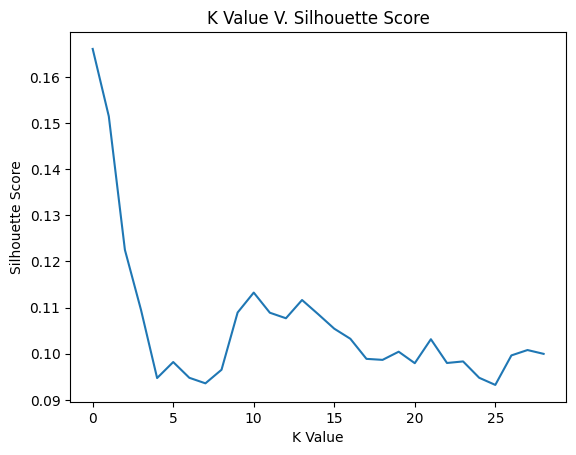

In [60]:
plt.plot(sil_scores)
plt.title("K Value V. Silhouette Score")
plt.ylabel('Silhouette Score')
plt.xlabel("K Value")

Text(0.5, 0, 'K Value')

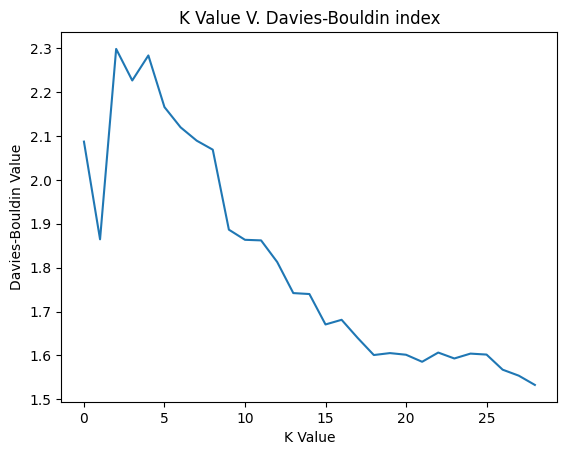

In [61]:
plt.plot(d_b_scores)
plt.title("K Value V. Davies-Bouldin index")
plt.ylabel('Davies-Bouldin Value')
plt.xlabel("K Value")

In [62]:
kmeans_4 = KMeans(n_clusters=4,random_state=6740)
predicted_labels_4 = kmeans_4.fit(data_pca).labels_

kmeans_6 = KMeans(n_clusters=6,random_state=6740)
predicted_labels_6 = kmeans_6.fit(data_pca).labels_

kmeans_10 = KMeans(n_clusters=10,random_state=6740)
predicted_labels_10 = kmeans_10.fit(data_pca).labels_

kmeans_8 = KMeans(n_clusters=8,random_state=6740)
predicted_labels_8 = kmeans_8.fit(data_pca).labels_



In [ ]:
master_passer_aggregate_data['label'] = predicted_labels_8


In [64]:
passer_year_id_label_dict = dict(zip(master_passer_aggregate_data['passer_name_year_id'],master_passer_aggregate_data['label']))

In [65]:
master_pbp_data['passer_player_name']=master_pbp_data['passer_player_name'].replace({'G.Minshew II':'G.Minshew', 'Aa.Rodgers':'A.Rodgers', 'Jos.Allen':'J.Allen'})

In [66]:
reg_data = master_pbp_data[(master_pbp_data['play_type']=='pass')&(master_pbp_data['passer_year_id'].isin(eligible_qb_ids))]

In [67]:
reg_data['passer_name_year_id'] = (reg_data['year'].astype(str)  + '_' +                                                                    
      reg_data['passer_player_name'].astype(str))

In [68]:
reg_data['label']=reg_data['passer_name_year_id'].map(passer_year_id_label_dict)

In [69]:
archetype_epa_v_coverage = reg_data.groupby(['label','defense_coverage_type'],as_index=False)['qb_epa'].mean()

In [70]:
archetype_epa_v_coverage=archetype_epa_v_coverage.pivot(columns='defense_coverage_type',index='label').fillna(0).droplevel([0],axis=1)

In [71]:
archetype_epa_v_coverage.columns.name = None  

In [72]:
archetype_epa_v_coverage=archetype_epa_v_coverage.astype(float)

keep_coverages = ['COVER_0', 'COVER_1', 'COVER_2', 'COVER_3', 'COVER_4', 'COVER_6']

archetype_epa_v_coverage=archetype_epa_v_coverage[keep_coverages]

In [123]:
archetype_epa_v_coverage

,COVER_0,COVER_1,COVER_2,COVER_3,COVER_4,COVER_6
label,,,,,,
0,0.099509,0.138953,0.234386,0.223261,0.220789,0.303493
1,-0.173359,-0.177182,-0.115952,-0.191691,-0.143383,-0.164815
2,0.044571,0.001903,0.041538,0.080342,0.084114,0.107791
3,0.151350,0.222496,0.117970,0.263043,0.158411,0.114009
4,0.003321,0.017156,0.000920,0.064506,-0.010738,0.042344
5,0.181363,0.295199,0.267103,0.258151,0.236264,0.234235
6,0.078296,0.049724,0.091112,0.099866,0.041291,0.055743
7,0.140252,0.138349,0.132606,0.177280,0.140404,0.066209


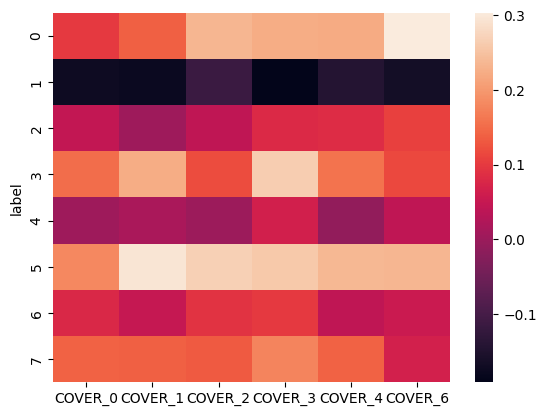

In [149]:
plt.ylabel('Archetype Label')
sns.heatmap(archetype_epa_v_coverage)
plt.savefig('foo.pdf')

In [ ]:
plt.savefig('foo.pdf')

In [74]:
reg_data_select_coverage = reg_data[reg_data['defense_coverage_type'].isin(keep_coverages)].reset_index(drop=True)

In [75]:
reg_data['passer_player_id']

9         00-0035228
10        00-0035228
11        00-0035228
12        00-0035228
13        00-0035228
             ...    
294981    00-0039851
294982    00-0039851
294985    00-0039851
294986    00-0039851
294987    00-0039851
Name: passer_player_id, Length: 106620, dtype: str

In [76]:
reg_data_select_coverage_clean = reg_data_select_coverage[['passer_player_id','label','qb_epa','defense_coverage_type','yardline_100','score_differential','down','ydstogo','offense_personnel','season']]

In [77]:

reg_data_select_coverage_clean['wr_count']=reg_data_select_coverage_clean['offense_personnel'].str.extract(r'(\d+)\s*WR').astype(float) 
reg_data_select_coverage_clean['rb_count']=reg_data_select_coverage_clean['offense_personnel'].str.extract(r'(\d+)\s*RB').astype(float) 
reg_data_select_coverage_clean['te_count']=reg_data_select_coverage_clean['offense_personnel'].str.extract(r'(\d+)\s*TE').astype(float) 

In [104]:
reg_data_select_coverage_clean[['yardline_100','score_differential','ydstogo','qb_epa']] = reg_data_select_coverage_clean[['yardline_100','score_differential','ydstogo','qb_epa']].astype(float)

In [107]:
cols_needed = ['qb_epa', 'defense_coverage_type', 'label', 'yardline_100',
                 'score_differential', 'season', 'down', 'ydstogo',
                 'wr_count', 'rb_count', 'te_count', 'passer_player_id']

reg_data_select_coverage_clean = reg_data_select_coverage_clean.dropna().reset_index(drop=True)
                                                                                                       
regression_sample = (reg_data_select_coverage_clean[cols_needed]                                     
                       .dropna()                                                                       
                       .sample(n=10000, random_state=6740)                                             
                       .reset_index(drop=True))    

In [ ]:
'C(defense_coverage_type) + C(label)'

In [115]:
ols_model = smf.ols(
    "qb_epa ~ C(defense_coverage_type) + C(label) + C(defense_coverage_type):C(label) + yardline_100 + score_differential + C(season) + C(down) + ydstogo + C(wr_count) + C(rb_count) + C(te_count)",
    data=reg_data_select_coverage_clean              
).fit(cov_type='cluster', cov_kwds={'groups': reg_data_select_coverage_clean['passer_player_id']})                
                                                                                                    


In [146]:
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 qb_epa   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     297.5
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.32e-74
Time:                        15:10:57   Log-Likelihood:            -1.7321e+05
No. Observations:               94047   AIC:                         3.466e+05
Df Residuals:                   93976   BIC:                         3.472e+05
Df Model:                          70                                         
Covariance Type:              cluster                                         
=====================================================================================================================
                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
Intercept                                             0.3771      0.234      1.613      0.107      -0.081       0.835
C(defense_coverage_type)[T.COVER_1]                   0.0483      0.116      0.416      0.677      -0.179       0.276
C(defense_coverage_type)[T.COVER_2]                   0.1524      0.108      1.413      0.158      -0.059       0.364
C(defense_coverage_type)[T.COVER_3]                   0.1171      0.084      1.397      0.163      -0.047       0.282
C(defense_coverage_type)[T.COVER_4]                   0.1304      0.137      0.949      0.343      -0.139       0.400
C(defense_coverage_type)[T.COVER_6]                   0.2119      0.050      4.246      0.000       0.114       0.310
C(label)[T.1]                                        -0.2094      0.142     -1.474      0.140      -0.488       0.069
C(label)[T.2]                                        -0.0217      0.162     -0.134      0.894      -0.340       0.296
C(label)[T.3]                                         0.0448      0.131      0.341      0.733      -0.212       0.302
C(label)[T.4]                                        -0.1031      0.162     -0.635      0.526      -0.421       0.215
C(label)[T.5]                                         0.0550      0.097      0.567      0.571      -0.135       0.245
C(label)[T.6]                                         0.0206      0.106      0.195      0.846      -0.187       0.228
C(label)[T.7]                                         0.1383      0.110      1.260      0.208      -0.077       0.353
C(season)[T.2021]                                    -0.0152      0.014     -1.061      0.289      -0.043       0.013
C(season)[T.2022]                                    -0.0078      0.017     -0.459      0.646      -0.041       0.025
C(season)[T.2023]                                    -0.0664      0.029     -2.286      0.022      -0.123      -0.009
C(season)[T.2024]                                    -0.0556      0.029     -1.899      0.058      -0.113       0.002
C(season)[T.2025]                                    -0.0704      0.028     -2.489      0.013      -0.126      -0.015
C(down)[T.2.0]                                       -0.0176      0.011     -1.653      0.098      -0.039       0.003
C(down)[T.3.0]                                       -0.1305      0.019     -7.039      0.000      -0.167      -0.094
C(down)[T.4.0]                                       -0.0606      0.062     -0.972      0.331      -0.183       0.062
C(wr_count)[T.1.0]                                   -0.0742      0.096     -0.770      0.441      -0.263       0.115
C(wr_count)[T.2.0]                                   -0.0626      0.100     -0.628      0.530      -0.258       0.133
C(wr_count)[T.3

In [117]:
ols_model_no_interaction = smf.ols(
    "qb_epa ~ C(defense_coverage_type) + C(label) + yardline_100 + score_differential + C(season) + C(down) + ydstogo + C(wr_count) + C(rb_count) + C(te_count)",
    data=reg_data_select_coverage_clean              
).fit(cov_type='cluster', cov_kwds={'groups': reg_data_select_coverage_clean['passer_player_id']})                
                                                                                                    
  

In [119]:
anova_lm(ols_model_no_interaction, ols_model)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,94011.0,219180.153095,0.0,NaN,NaN,NaN
1,93976.0,219090.163443,35.0,89.989652,1.102855,0.310176


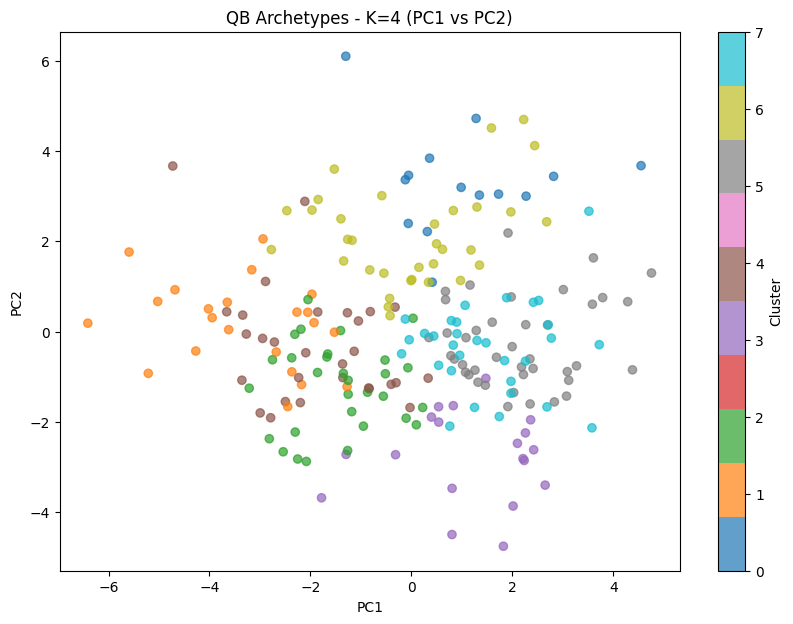

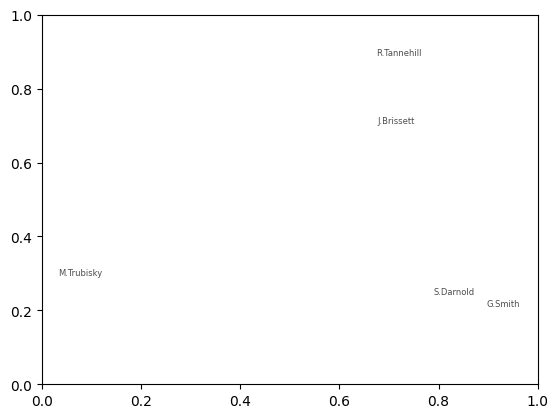

In [80]:
plt.figure(figsize=(10, 7))                                                             
scatter = plt.scatter(data_pca[:, 0], data_pca[:, 1],                                   
                    c=predicted_labels_8, cmap='tab10', alpha=0.7)                    
plt.colorbar(scatter, label='Cluster')                                                  
plt.xlabel('PC1')
plt.ylabel('PC2')                                                                       
plt.title('QB Archetypes - K=4 (PC1 vs PC2)')
plt.show()                                                                              

# If you want to add player name labels for the qualitative check:                        
                
for i, name in enumerate(master_passer_aggregate_data['passer_name']):                  
    plt.annotate(name, (data_pca[i, 0], data_pca[i, 1]), fontsize=6, alpha=0.7)  